In [4]:
!pip3 install numpy matplotlib seaborn scikit-image scikit-learn mlxtend


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# **1. Dataset Preparation**

In [5]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from mlxtend.data import loadlocal_mnist

In [6]:
import os

print(os.getcwd())

c:\Users\USER\OneDrive\Dokumen\Aldin\UTS Computer Vision


In [7]:
from mlxtend.data import loadlocal_mnist

data_images, data_labels = loadlocal_mnist(
    images_path="emnist-letters-train-images-idx3-ubyte",
    labels_path="emnist-letters-train-labels-idx1-ubyte"
)

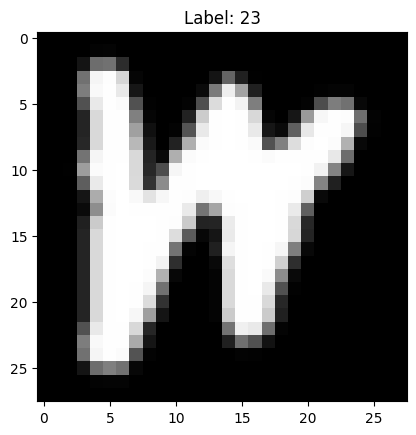

In [8]:
plt.imshow(data_images[0].reshape(28,28).T, cmap='gray')
plt.title(f"Label: {data_labels[0]}")
plt.show()

In [9]:
print("Jumlah gambar:", len(data_images))
print("Jumlah label :", len(data_labels))

Jumlah gambar: 124800
Jumlah label : 124800


In [10]:
data_labels = data_labels - 1

In [11]:
data_images = np.array(data_images)
data_labels = np.array(data_labels)

selected_images = []
selected_labels = []

for class_idx in range(26):
    idx = np.where(data_labels == class_idx)[0]
    if len(idx) >= 100:
        selected_idx = np.random.choice(idx, 100, replace=False)
        selected_images.append(data_images[selected_idx])
        selected_labels.append(data_labels[selected_idx])
    else:
        print(f"Kelas {class_idx} kosong, hanya ada {len(idx)} gambar.")

X_subset = np.vstack(selected_images)
y_subset = np.hstack(selected_labels)

print("Jumlah x_subset:", len(X_subset))
print("Jumlah y_subset :", len(y_subset))

Jumlah x_subset: 2600
Jumlah y_subset : 2600


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42, stratify=y_subset
)

print("Jumlah x_train:", len(X_train))
print("Jumlah y_train :", len(y_train))
print("Jumlah x_test :", len(X_test))
print("Jumlah y_test :", len(y_test))

Jumlah x_train: 2080
Jumlah y_train : 2080
Jumlah x_test : 520
Jumlah y_test : 520


# **2. Feature Extraction**

In [13]:
feature, hog_img = hog(X_train[0].reshape(28,28), orientations=8, pixels_per_cell=(4, 4), cells_per_block=(2,2), visualize=True, block_norm='L2')

feature.shape

(1152,)

<BarContainer object of 1152 artists>

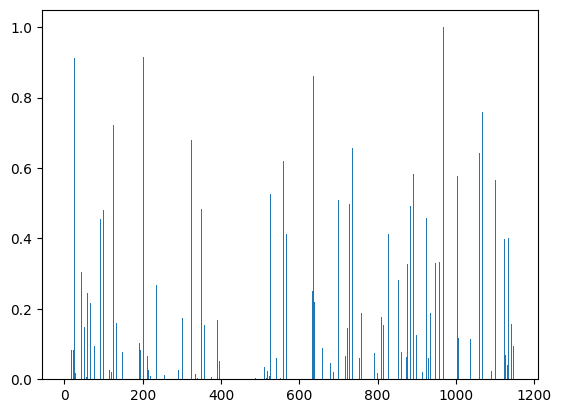

In [14]:
plt.bar(list(range(feature.shape[0])), feature)

In [15]:
def hog_features(images, orientations=8, pixels_per_cell=(8, 8), cells_per_block=(2, 2)):
    features = []
    for image in images:
        feature = hog(image.reshape(28, 28), orientations=orientations,
                      pixels_per_cell=pixels_per_cell,
                      cells_per_block=cells_per_block,
                      block_norm='L2')
        features.append(feature)
    return np.array(features)

In [16]:
orientations = 8
pixels_per_cell = (4, 4)
cells_per_block = (2, 2)

In [17]:
X_train_hog = hog_features(X_train, orientations, pixels_per_cell, cells_per_block)
X_test_hog = hog_features(X_test, orientations, pixels_per_cell, cells_per_block)

In [18]:
print("X_train_hog shape:", X_train_hog.shape)
print("X_test_hog shape :", X_test_hog.shape)

X_train_hog shape: (2080, 1152)
X_test_hog shape : (520, 1152)


# **3. Classification**

In [19]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

In [20]:
svm = SVC()
grid_search = GridSearchCV(svm, param_grid, cv=2, n_jobs=-1, verbose=2)

In [21]:
grid_search.fit(X_train_hog, y_train)

Fitting 2 folds for each of 30 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3

In [22]:
print("Best Parameters:", grid_search.best_params_)
print("Performance:", grid_search.best_estimator_.score(X_test_hog, y_test))

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Performance: 0.823076923076923


In [23]:
best_model = grid_search.best_estimator_ 

# **4. Evaluation**

In [24]:
y_test_pred = best_model.predict(X_test_hog)

print("=== Test Set Evaluation ===")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

=== Test Set Evaluation ===
Accuracy : 0.823076923076923

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.60      0.67        20
           1       0.85      0.85      0.85        20
           2       0.77      1.00      0.87        20
           3       0.94      0.85      0.89        20
           4       1.00      0.90      0.95        20
           5       0.83      0.95      0.88        20
           6       0.64      0.70      0.67        20
           7       0.84      0.80      0.82        20
           8       0.54      0.65      0.59        20
           9       0.81      0.85      0.83        20
          10       0.82      0.90      0.86        20
          11       0.64      0.45      0.53        20
          12       0.85      0.85      0.85        20
          13       0.73      0.80      0.76        20
          14       0.83      0.95      0.88        20
          15       0.94      0.80      0.86        20

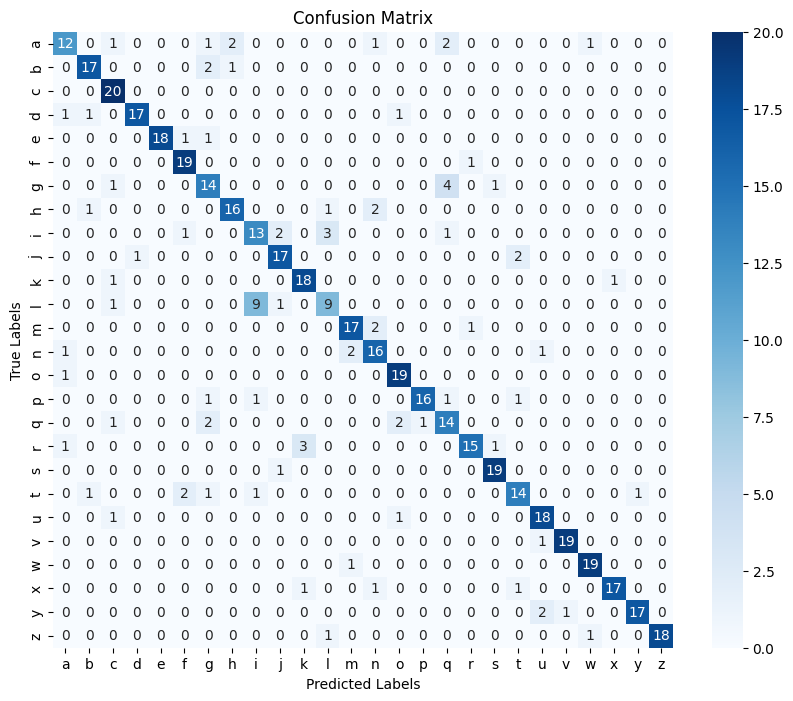

In [25]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[chr(i + 97) for i in range(26)], yticklabels=[chr(i + 97) for i in range(26)])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

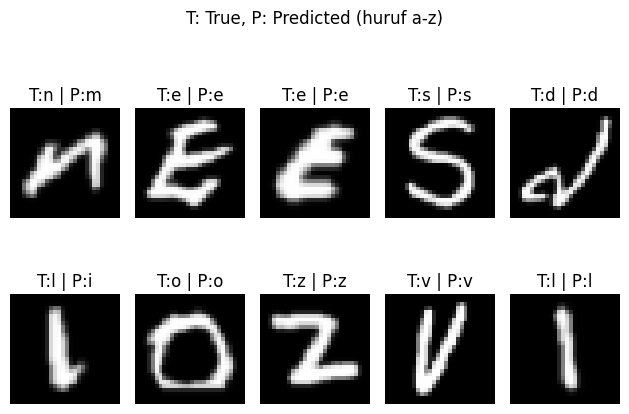

In [26]:
indices = random.sample(range(len(X_test)), 10)

for i, idx in enumerate(indices):
    img = X_test[idx].reshape(28, 28).T 
    true_label = y_test[idx] 
    pred_label = y_test_pred[idx] 

    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"T:{chr(true_label + 97)} | P:{chr(pred_label + 97)}") 
    plt.axis('off')

plt.suptitle("T: True, P: Predicted (huruf a-z)")
plt.tight_layout()
plt.show()